# Adult Census Income Dataset Analysis

**Objective:** predict whether a person earns more or less than USD 50,000 a year based on demographic and employment variables (the *Adult* dataset from the UCI Machine Learning Repository), applying a full process of cleaning, preprocessing, classification (Decision Tree), and clustering (DBSCAN). It also includes an analysis of the ethical and privacy risks associated with using this type of data.

**Tools:** Python, pandas, scikit-learn, matplotlib, seaborn.

**Data source:** [UCI Machine Learning Repository - Adult Data Set](https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data)


In [1]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
df = pd.read_csv(url, names=columns, na_values=' ?', skipinitialspace=True)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_samples, silhouette_score, confusion_matrix, accuracy_score, precision_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

In [3]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
for column in df.columns:
    print(f"Unique values for '{column}':\n{df[column].unique()}\n")

Unique values for 'age':
[39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87]

Unique values for 'workclass':
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']

Unique values for 'fnlwgt':
[ 77516  83311 215646 ...  34066  84661 257302]

Unique values for 'education':
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']

Unique values for 'education-num':
[13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]

Unique values for 'marital-status':
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']

Unique values for 'occupation':
['Adm-clerical' 'Exec-managerial' 'Handlers-clea

## 1. Handling missing values

I convert the missing values marked as '?' into null values before removing or working with them, so the process is more standardized.

In [6]:
df = df.replace('?', pd.NA)

In [7]:
for column in df.columns:
    print(f"Unique values for '{column}':\n{df[column].unique()}\n")

Unique values for 'age':
[39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87]

Unique values for 'workclass':
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' <NA>
 'Self-emp-inc' 'Without-pay' 'Never-worked']

Unique values for 'fnlwgt':
[ 77516  83311 215646 ...  34066  84661 257302]

Unique values for 'education':
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']

Unique values for 'education-num':
[13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]

Unique values for 'marital-status':
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']

Unique values for 'occupation':
['Adm-clerical' 'Exec-managerial' 'Handlers-cle

In [8]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


In [9]:
#Remove null values
print(f"Rows before removing: {len(df)}")

df_clean = df.dropna().copy()  # removes any row with at least one null value

print(f"Rows after removing: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")


Rows before removing: 32561
Rows after removing: 30162
Rows removed: 2399


In [10]:
df_clean.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


2399 rows were removed. This is a moderate but non-negligible amount; it was still decided to remove them because, as analyzed below, the nulls are not random — they have a reasonable logical explanation — and the resulting dataset is still large enough for the analysis.

Other options to replace the nulls would be:

*   For numeric variables, they could be replaced with the median, which is a better parameter than, for example, the mean, since it is not affected by outliers.
*   For categorical variables, one option could be to replace the categorical values with the mode, which, being the most frequent value, preserves the trend of the data. Values could also be imputed based on other columns related to the column being treated.

In both cases, the null could also be replaced with a label like "unknown" or "no data", depending on the evaluation of the variables.


### Additional analysis: relationship between nulls in 'workclass' and 'occupation'

I wanted to check whether the nulls in "workclass" and "occupation" were related to each other.

In [11]:
# Check whether the workclass nulls coincide with occupation nulls
print(df[df['workclass'].isnull()]['occupation'].isnull().sum())
print(df['workclass'].isnull().sum())


1836
1836


In [12]:
mask = df['occupation'].isnull() & df['workclass'].notnull()
df[mask][['workclass', 'occupation']]

,workclass,occupation
5361,Never-worked,<NA>
10845,Never-worked,<NA>
14772,Never-worked,<NA>
20337,Never-worked,<NA>
23232,Never-worked,<NA>
32304,Never-worked,<NA>
32314,Never-worked,<NA>


I see that the 1836 rows with no "workclass" are exactly the same ones that have no "occupation" — in other words, the same group of people who reported nothing about their employment status also do not have a formal job. I also noticed that 7 nulls in "occupation" correspond to people with "workclass": "Never-worked" — since they never worked, there is no occupation.
I see that the null values are not random, but are related to the actual employment situation of those people. That's why, if instead of removing them I had replaced the values, in this case I would not have used the mode, because that would mean assuming those people work when it seems they don't, which could distort the analysis. So I would create a new category called "Unknown".

## 2. Outlier detection and treatment

In [13]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
age,30162.0,38.437902,13.134665,17.0,28.00,37.0,47.0,90.0
fnlwgt,30162.0,189793.833930,105652.971529,13769.0,117627.25,178425.0,237628.5,1484705.0
education-num,30162.0,10.121312,2.549995,1.0,9.00,10.0,13.0,16.0
capital-gain,30162.0,1092.007858,7406.346497,0.0,0.00,0.0,0.0,99999.0
capital-loss,30162.0,88.372489,404.298370,0.0,0.00,0.0,0.0,4356.0
hours-per-week,30162.0,40.931238,11.979984,1.0,40.00,40.0,45.0,99.0


In [14]:
v_num = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

In [15]:
#evaluate the numeric variables, excluding fnlwgt because it doesn't add value to the analysis

for col in v_num:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df_clean)*100}%) | limits: [{lower}, {upper}]")


age: 169 outliers (0.560307671905046%) | limits: [-0.5, 75.5]
education-num: 196 outliers (0.6498242822094025%) | limits: [3.0, 19.0]
capital-gain: 2538 outliers (8.41456136860951%) | limits: [0.0, 0.0]
capital-loss: 1427 outliers (4.731118626085803%) | limits: [0.0, 0.0]
hours-per-week: 7953 outliers (26.367614879649892%) | limits: [32.5, 52.5]


The limits for capital-gain and capital-loss come out as 0. This happens because the Q1, median, and Q3 of those columns are 0 (more than 90% of the values are zero), so the IQR is 0 and any different value gets flagged as an outlier. They are not removed, but the correct analysis is the one in the next cell (153 and 53 real outliers over the non-zero values).

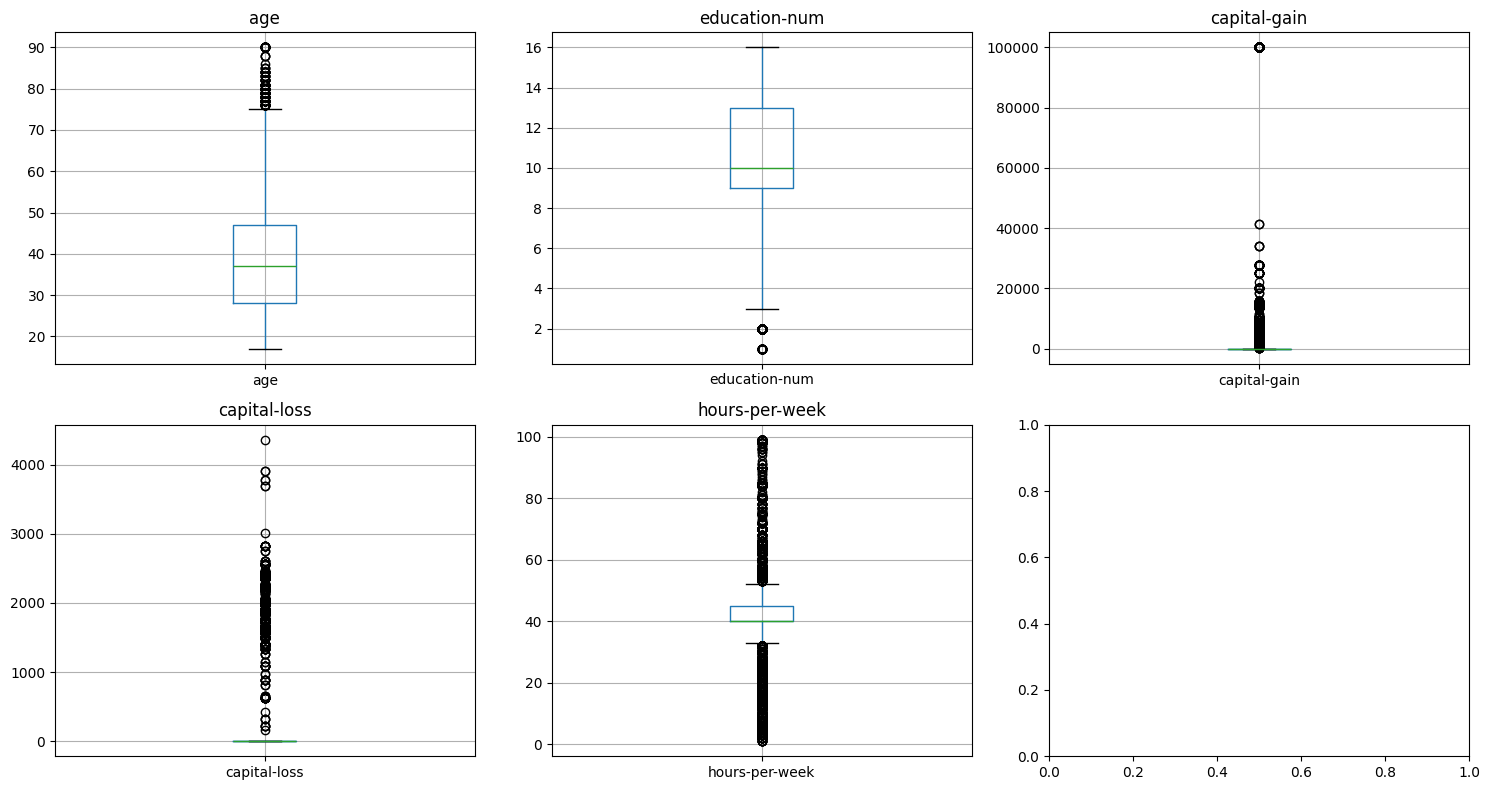

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), v_num):
    df_clean.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [17]:
# For capital-gain and capital-loss: most values are zero, checked separately
for col in ['capital-gain', 'capital-loss']:
    zero_pct = (df_clean[col] == 0).mean() * 100
    print(f"{col}: {zero_pct:.1f}% are zeros")

for col in ['capital-gain', 'capital-loss']:
    nonzero = df_clean[df_clean[col] > 0][col]
    Q1 = nonzero.quantile(0.25)
    Q3 = nonzero.quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    outliers = nonzero[nonzero > upper]
    print(f"{col}: out of {len(nonzero)} non-zero values, {len(outliers)} outliers, upper limit: {upper:.1f}")


capital-gain: 91.6% are zeros
capital-loss: 95.3% are zeros
capital-gain: out of 2538 non-zero values, 153 outliers, upper limit: 30014.0
capital-loss: out of 1427 non-zero values, 53 outliers, upper limit: 2434.5


There are outliers, but they are not removed because most of them appear to be real values (actual gains or losses), and the repeated peak at 99999 seems to be a cap imposed by the census itself, not an error.
Removing those rows would mean discarding real information and biasing the sample. In "age", the outliers would also correspond to real cases (e.g., older people still working), so they are not removed either.
For hours-per-week, the 26.4% of outliers detected by IQR is a high number, but this is because the distribution is heavily concentrated around 40 hours, which produces very strict limits. This doesn't reflect real extreme values, but rather the nature of the distribution: working part-time or overtime is common in a real population, not an error. That's why no records are removed from this column.

## 3. Encoding the target variable (Label Encoding)

In [18]:
le = LabelEncoder()
df_clean['income_encoded'] = le.fit_transform(df_clean['income'])

print(dict(zip(le.classes_, le.transform(le.classes_))))
df_clean[['income', 'income_encoded']].head()

{'<=50K': np.int64(0), '>50K': np.int64(1)}


,income,income_encoded
0,<=50K,0
1,<=50K,0
2,<=50K,0
3,<=50K,0
4,<=50K,0


In [19]:
df_clean

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,income_encoded
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K,0
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K,1
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K,0
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K,0


## 4. Final preprocessing (One-Hot Encoding and variable selection)

In [20]:
df_model = df_clean.drop(columns=['education', 'fnlwgt', 'income'])
"""'education' is removed because it is redundant with 'education-num'; 'fnlwgt' is removed because it is not a characteristic of the person;
'income' is removed because its numeric equivalent is already available"""

# Label Encoding for 'sex' ---
le_sex = LabelEncoder()
df_model['sex'] = le_sex.fit_transform(df_model['sex'])

# One-Hot Encoding for the rest of the categorical variables
cat_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']

ohe = OneHotEncoder(sparse_output=False, drop='first')
ohe.set_output(transform="pandas")
v_cat = ohe.fit_transform(df_model[cat_cols])

v_num = df_model.drop(columns=cat_cols)

df_model = pd.concat([v_num, v_cat], axis=1)

print(df_model.shape)
df_model.head()


(30162, 81)


,age,education-num,sex,capital-gain,capital-loss,hours-per-week,income_encoded,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,13,1,2174,0,40,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,50,13,1,0,0,13,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,38,9,1,0,0,40,0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,53,7,1,0,0,40,0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,28,13,0,0,0,40,0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The problem with applying One-Hot Encoding is that columns with many categories will generate many new columns, greatly increasing dimensionality. The alternative, Label Encoding, would avoid this, but it would create an artificial order between categories that doesn't exist in reality.

## 5. Train/test split

In [21]:
X = df_model.drop(columns=['income_encoded'])

In [22]:
y = df_model['income_encoded']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))

(24129, 80) (6033, 80)
income_encoded
0    0.751088
1    0.248912
Name: proportion, dtype: float64


I chose an 80% / 20% split because the dataset is very large, which allows leaving 20% for testing without giving up too much training data. I used stratify=y because the income classes are imbalanced (76%/24%), so this preserves that proportion in both sets.

## 6. Model training and evaluation

### 6.1 Decision Tree

In [24]:
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

y_pred_dt = dt_clf.predict(X_test)

The Decision Tree is a model that's easy to interpret, doesn't require variable scaling, and handles both numeric and categorical variables well, but it is prone to overfitting and has high variance — it is sensitive to small changes in the training data.
A possible replacement would be Random Forest, an ensemble of multiple trees trained on random subsets of data and variables, which reduces overfitting and variance while keeping interpretability.

In [25]:
cm = confusion_matrix(y_test, y_pred_dt)
print("Confusion matrix:")
print(cm)

acc = accuracy_score(y_test, y_pred_dt)
print(f"\nAccuracy: {acc}")

prec = precision_score(y_test, y_pred_dt)
print(f"Precision: {prec}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


Confusion matrix:
[[3998  533]
 [ 558  944]]

Accuracy: 0.8191612796287088
Precision: 0.6391333784698714

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      4531
           1       0.64      0.63      0.63      1502

    accuracy                           0.82      6033
   macro avg       0.76      0.76      0.76      6033
weighted avg       0.82      0.82      0.82      6033



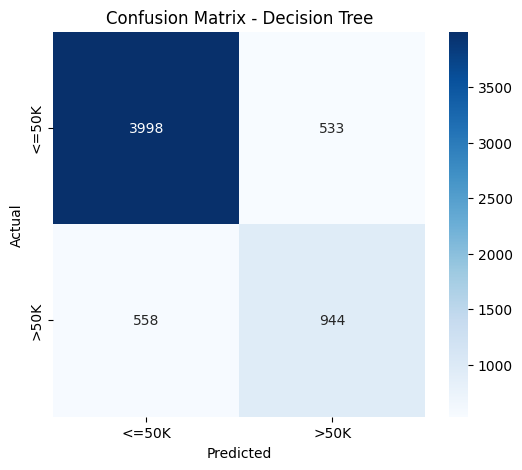

In [26]:
# Confusion matrix visualization
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()


The model achieved an accuracy of 0.82, meaning it gets it right 8 out of 10 times.
But this number alone doesn't say much, because the classes are imbalanced (75% earn <=50K and 25% earn more), so a model that always predicted <=50K would already have a similar accuracy without having actually learned anything.
That's why I looked at the metrics broken down by class. For <=50K the model performs well (precision and recall of 0.88), but for >50K it drops quite a bit: precision of 0.64 and recall of 0.63. This means that out of the people the model predicts earn more than 50K, almost 4 out of 10 actually don't earn that much, and it misses 37% of the real >50K cases (misclassifying them as earning less).
This can be seen in the confusion matrix: out of 1502 real >50K cases, it got 944 right but missed 558. This makes sense, since the dataset has fewer examples of people earning more than 50K, so the model had less data to learn that pattern from. To fix this, the first thing to do would be to look at the class balance and try oversampling or undersampling before touching anything else.

### 6.2 Clustering with DBSCAN (scaled variables + PCA)

In [27]:
# Scaling
# Necessary because the variables have very different ranges from one another
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# PCA to 2 components
# To reduce dimensionality before DBSCAN, and to be able to plot the clusters on a plane
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Variance explained by the 2 components: {pca.explained_variance_ratio_.sum()}")

# DBSCAN
dbscan = DBSCAN(eps=0.05, min_samples=50)
labels = dbscan.fit_predict(X_pca)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f"Clusters found: {n_clusters}")
print(f"Noise points: {n_noise} ({n_noise/len(labels):.2%})")


Variance explained by the 2 components: 0.2734273367314217
Clusters found: 34
Noise points: 2796 (9.27%)


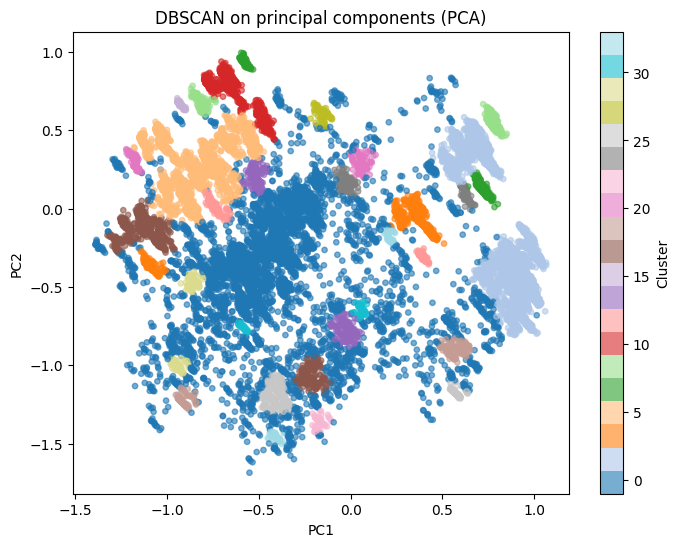

In [28]:
# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab20', s=15, alpha=0.6)
plt.title('DBSCAN on principal components (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Cluster')
plt.show()


In [29]:
# Evaluation with Silhouette Score
# Applied directly on the DBSCAN result, excluding noise since it doesn't belong to any real cluster
mask = labels != -1
score = silhouette_score(X_pca[mask], labels[mask])
print(f"Silhouette score: {score}")


Silhouette score: 0.31764806548858426


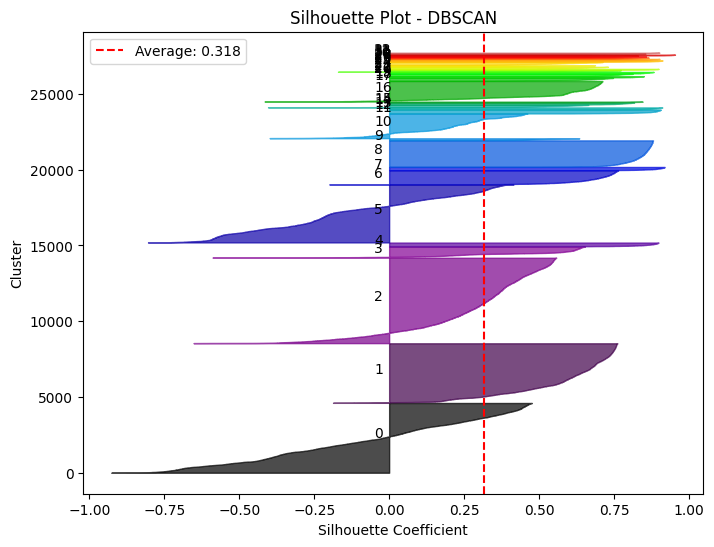

In [30]:
#Silhouette plot
X_filtered = X_pca[mask]
labels_filtered = labels[mask]

sample_silhouette_values = silhouette_samples(X_filtered, labels_filtered)
unique_clusters = np.unique(labels_filtered)
n_clusters_plot = len(unique_clusters)

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10

for idx, i in enumerate(unique_clusters):
    cluster_i_values = np.sort(sample_silhouette_values[labels_filtered == i])
    cluster_i_size = len(cluster_i_values)
    y_upper = y_lower + cluster_i_size

    color = plt.cm.nipy_spectral(float(idx) / n_clusters_plot)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_i_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * cluster_i_size, str(i))
    y_lower = y_upper + 10

ax.axvline(x=score, color="red", linestyle="--", label=f"Average: {score:.3f}")
ax.set_title("Silhouette Plot - DBSCAN")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.legend()
plt.show()


To apply DBSCAN I had to scale the variables and reduce everything to 2 components with PCA, because otherwise variables like capital-gain would weigh much more heavily than the others in the distance calculation, and this also allowed me to plot it.

Note: the 2 components only explain 27% of the total variance, meaning a fair amount of information is lost when compressing everything down to just 2 dimensions.

With eps=0.05 and min_samples=50 I got 34 clusters, with 9.27% of the points left as noise. The silhouette score was 0.318, which isn't bad but isn't spectacular either — it indicates the clusters are separated, but not very sharply.

The silhouette plot shows that not all clusters are equally well formed: some have high coefficients (fairly compact, well-differentiated groups) while others are lower, close to zero, meaning they overlap somewhat with neighboring clusters.

Unlike the decision tree, here DBSCAN knows nothing about "income" — it only groups similar people together based on their other characteristics. The result (34 groups, none clearly dominant, with moderate separation) shows that the census population doesn't split into a few sharply defined blocks, but rather into several smaller subgroups with somewhat different profiles. Still, since the PCA retained little explained variance, this conclusion should be taken with caution, not as something definitive.

### Additional comparison: DBSCAN without PCA (on the original variables)

In [31]:
# A sample of 3000 points is used

# Reproducible random sample
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=3000, replace=False)
X_sample_full = X_scaled[sample_idx]

# Sweep over eps to find a reasonable value
for eps_val in [1.1, 1.2, 1.3, 1.4]:
    db = DBSCAN(eps=eps_val, min_samples=50)
    lab = db.fit_predict(X_sample_full)
    n_clust = len(set(lab)) - (1 if -1 in lab else 0)
    n_noise_pct = (list(lab).count(-1) / len(lab)) * 100
    print(f"eps={eps_val}: {n_clust} clusters, {n_noise_pct}% noise")

print()

# Final DBSCAN with the chosen eps
dbscan_full = DBSCAN(eps=1.2, min_samples=50)
labels_sample = dbscan_full.fit_predict(X_sample_full)

n_clusters_sample = len(set(labels_sample)) - (1 if -1 in labels_sample else 0)
n_noise_sample = list(labels_sample).count(-1)
print(f"Clusters: {n_clusters_sample}")
print(f"Noise: {n_noise_sample} ({n_noise_sample/len(labels_sample)})")

# Silhouette score on the sample (excluding noise)
mask_sample = labels_sample != -1
score_sample = silhouette_score(X_sample_full[mask_sample], labels_sample[mask_sample])
print(f"Silhouette (sample, no PCA): {score_sample:}")


eps=1.1: 5 clusters, 34.9% noise
eps=1.2: 5 clusters, 33.4% noise
eps=1.3: 5 clusters, 33.166666666666664% noise
eps=1.4: 5 clusters, 33.1% noise

Clusters: 5
Noise: 1002 (0.334)
Silhouette (sample, no PCA): 0.24343224634441185


I tried applying DBSCAN directly on the 80 original variables (without PCA), using a sample of 3000 points because of how long it took on the full dataset. With eps=1.2 and min_samples=50 I got 5 clusters, with 33.40% noise (1002 points) and a silhouette score of 0.243.

Comparing it with the earlier version (with PCA, eps=0.05, min_samples=50): 34 clusters, 9.27% noise, silhouette of 0.318 — the PCA version gives better results on both metrics that matter: less noise and better separation between clusters. Without PCA, almost a third of the points fail to group into any cluster, and the silhouette score is lower.

## Conclusions

- After cleaning (removing nulls in 'workclass', 'occupation', and 'native-country'), the resulting dataset was smaller but consistent, without introducing significant bias since the nulls were not concentrated in a particular income class.
- The **Decision Tree** achieved an accuracy of 0.82, acceptable as a first baseline model, though insufficient on its own given the dataset's class imbalance (it is recommended to complement it with metrics such as precision/recall or F1 per class).
- **DBSCAN** with PCA reduction made it possible to identify natural groupings in the data, although with some loss of interpretability of the original variables; the comparison without PCA confirmed that dimensionality reduction was necessary to obtain interpretable clusters within a reasonable amount of time.
- The ethical analysis points out that variables such as *race*, *sex*, and *native-country* require careful handling to avoid both indirect identification of individuals and discriminatory use of the model's predictions in sensitive contexts (e.g., credit, hiring).
